# Marketing Mix Modeling

# Phase 3

## Outlier Detection & Treatment

Objective

- Detect outliers in all variables
- Understand their impact
- Winsorize extreme observations
- Produce a cleaned modelling dataset

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
raw_data = pd.read_csv("../data/raw/raw_data.csv")

raw_data["Week"] = pd.to_datetime(raw_data["Week"])

raw_data.head()

,State,Week,Salesforce,Email,Website,TV,Meta,Instagram,Influencer,Year,Month,Quarter,Week_Number,Month_End,Quarter_End,Festival,Holiday,Sales
0,Andhra Pradesh,2023-01-02,496,13205,76588,495,522380,1020933,19,2023,1,1,1,False,False,1,1,564
1,Andhra Pradesh,2023-01-09,2003,11825,28198,500,893916,1127800,4,2023,1,1,2,False,False,1,1,720
2,Andhra Pradesh,2023-01-16,1740,4652,57482,404,1433245,1422521,23,2023,1,1,3,False,False,1,1,833
3,Andhra Pradesh,2023-01-23,1265,27191,92730,226,1886417,1309921,23,2023,1,1,4,False,False,1,1,880
4,Andhra Pradesh,2023-01-30,1253,16403,45363,408,1486410,1110026,25,2023,1,1,5,True,False,1,1,870


In [3]:
model_variables = [
    "Sales",
    "Salesforce",
    "Email",
    "Website",
    "TV",
    "Meta",
    "Instagram",
    "Influencer"
]

In [4]:
print("Rows :", raw_data.shape[0])
print("Columns :", raw_data.shape[1])

Rows : 4396
Columns : 18


In [5]:
raw_data[model_variables].isnull().sum()

Sales         0
Salesforce    0
Email         0
Website       0
TV            0
Meta          0
Instagram     0
Influencer    0
dtype: int64

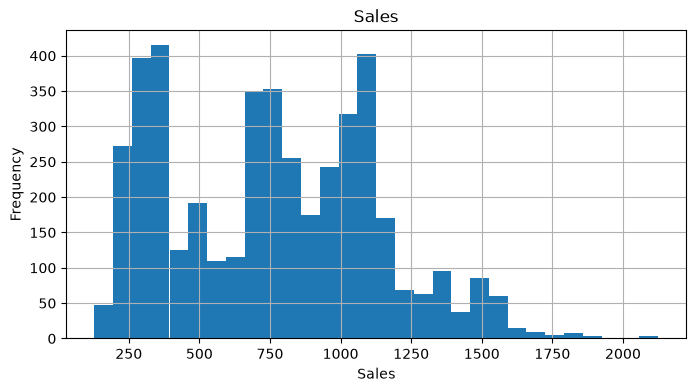

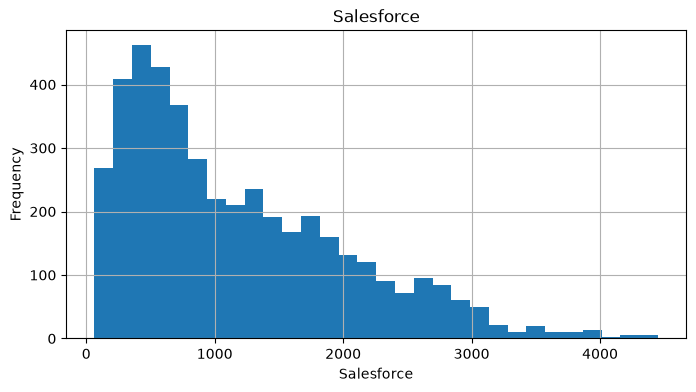

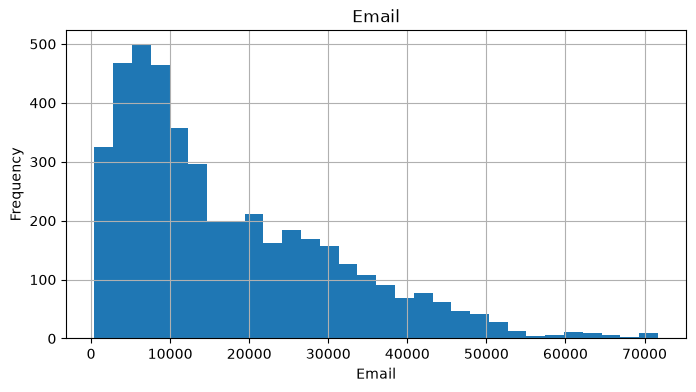

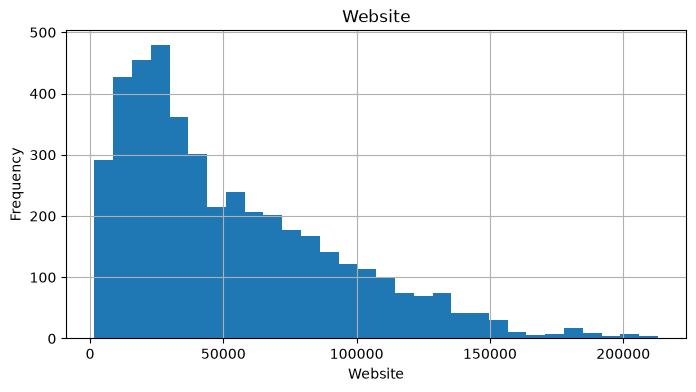

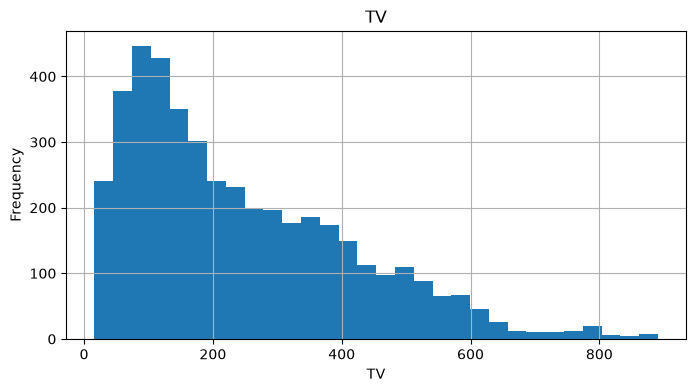

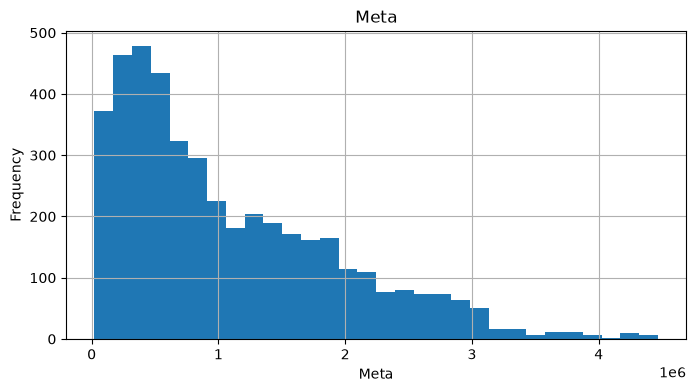

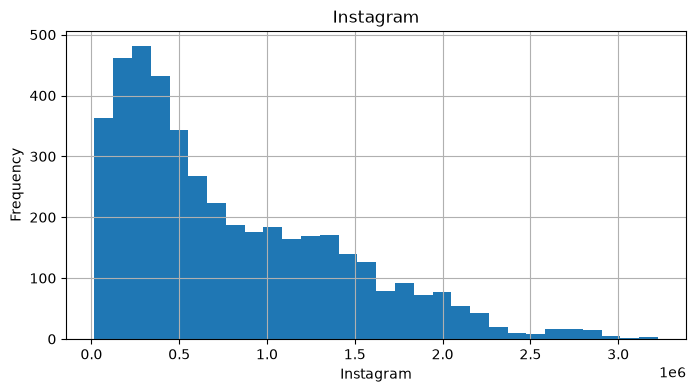

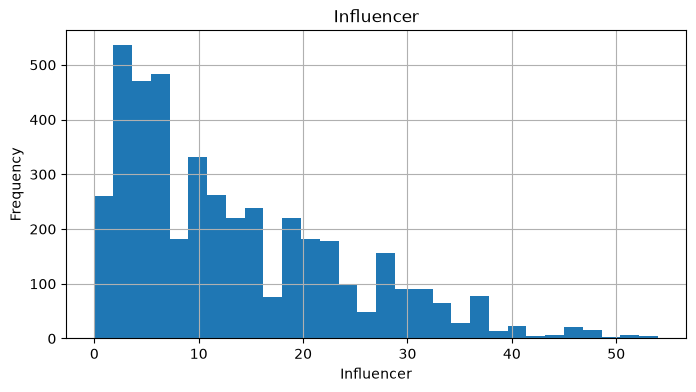

In [6]:
for variable in model_variables:

    plt.figure(figsize=(8,4))

    plt.hist(
        raw_data[variable],
        bins=30
    )

    plt.title(variable)

    plt.xlabel(variable)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

C:\Users\Hreetik\AppData\Local\Temp\ipykernel_620\618070194.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


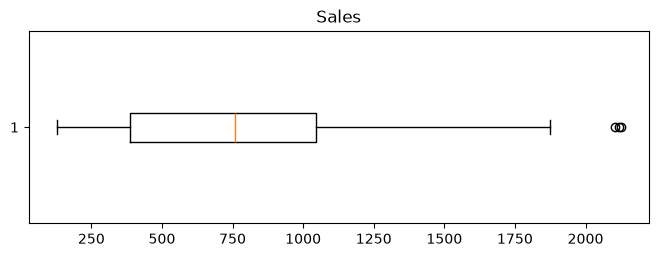

C:\Users\Hreetik\AppData\Local\Temp\ipykernel_620\618070194.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


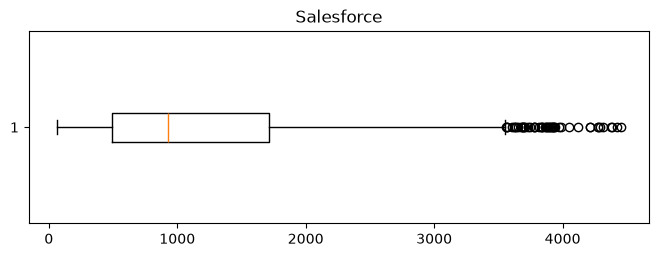

C:\Users\Hreetik\AppData\Local\Temp\ipykernel_620\618070194.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


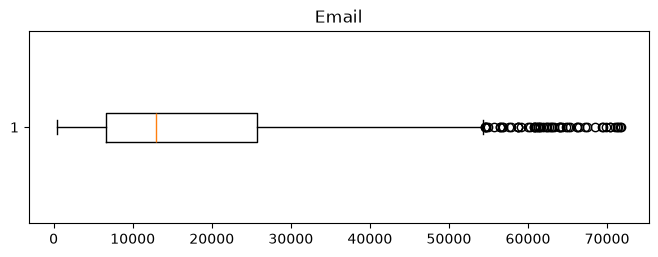

C:\Users\Hreetik\AppData\Local\Temp\ipykernel_620\618070194.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


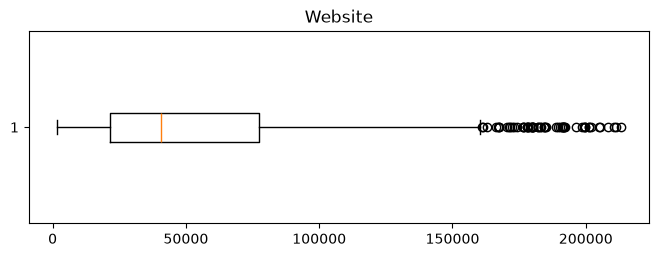

C:\Users\Hreetik\AppData\Local\Temp\ipykernel_620\618070194.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


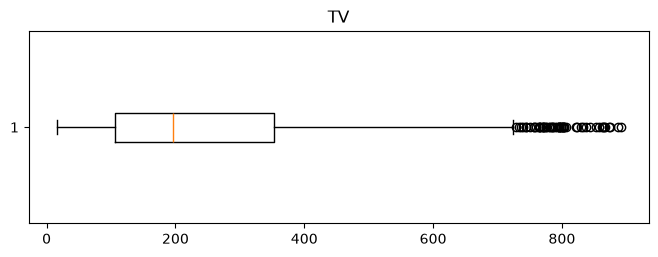

C:\Users\Hreetik\AppData\Local\Temp\ipykernel_620\618070194.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


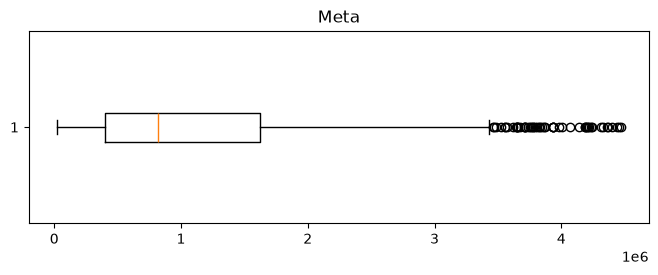

C:\Users\Hreetik\AppData\Local\Temp\ipykernel_620\618070194.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


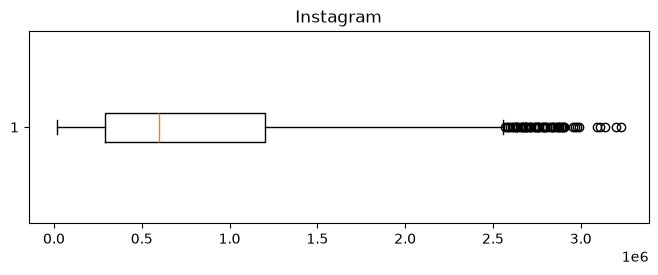

C:\Users\Hreetik\AppData\Local\Temp\ipykernel_620\618070194.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


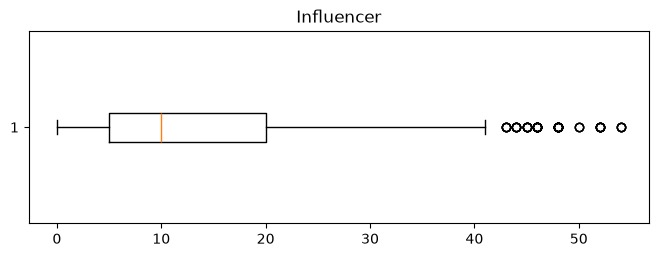

In [7]:
for variable in model_variables:

    plt.figure(figsize=(8,2.5))

    plt.boxplot(
        raw_data[variable],
        vert=False
    )

    plt.title(variable)

    plt.show()

In [8]:
from outlier import (
    calculate_iqr_bounds,
    identify_outliers,
    winsorize_series
)

In [9]:
summary = []

for variable in model_variables:

    outliers = identify_outliers(
        raw_data[variable]
    )

    summary.append({

        "Variable": variable,

        "Outliers": outliers.sum(),

        "Percentage":
        round(
            outliers.mean()*100,
            2
        )

    })

summary = pd.DataFrame(summary)

summary

,Variable,Outliers,Percentage
0,Sales,3,0.07
1,Salesforce,49,1.11
2,Email,56,1.27
3,Website,58,1.32
4,TV,56,1.27
5,Meta,54,1.23
6,Instagram,59,1.34
7,Influencer,61,1.39


In [10]:
flagged_data = raw_data.copy()

for variable in model_variables:

    flagged_data[
        variable + "_Outlier"
    ] = identify_outliers(
        raw_data[variable]
    )

In [11]:
cleaned_data = raw_data.copy()

for variable in model_variables:

    cleaned_data[variable] = winsorize_series(
        cleaned_data[variable]
    )

In [12]:
comparison = pd.DataFrame({

    "Before Mean":
    raw_data[model_variables].mean(),

    "After Mean":
    cleaned_data[model_variables].mean(),

    "Before Max":
    raw_data[model_variables].max(),

    "After Max":
    cleaned_data[model_variables].max()

})

comparison

,Before Mean,After Mean,Before Max,After Max
Sales,7.595523e+02,7.594980e+02,2124,2036.000
Salesforce,1.172584e+03,1.168628e+03,4451,3549.625
Email,1.725968e+04,1.715302e+04,71704,54379.250
Website,5.287342e+04,5.255241e+04,213035,160792.250
TV,2.429488e+02,2.419995e+02,891,724.125
Meta,1.081215e+06,1.075491e+06,4467549,3449218.625
Instagram,7.908305e+05,7.877584e+05,3226712,2564089.875
Influencer,1.318085e+01,1.311363e+01,54,42.500


In [13]:
output_folder = Path("../data/processed")

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

flagged_data.to_csv(
    output_folder / "raw_data_outliers_flagged.csv",
    index=False
)

cleaned_data.to_csv(
    output_folder / "raw_data_cleaned.csv",
    index=False
)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!
